# Первый урок — вспоминаем Python и высшую математику

Всё что будет здесь описано - это ответы на вопросы по [курсу](https://stepik.org/course/401/syllabus "Переходим, не стесняемся") и рефлексия на смежные темы.

> Что такое tuple (он же кортеж), чем он отличается от переменной типа list (список)? Как создать свой список/кортеж?

In [1]:
# ======================
# LIST (СПИСОК)
# ======================

# Классическое создание через квадратные скобки
my_list = [10, 20, 30, 40]
print(f"Тип my_list: {type(my_list)}")

# Список может содержать смешанные типы
mixed_list = [1, "hello", 3.14, None]
print(f"Список: {mixed_list}")

# ======================
# TUPLE (КОРТЕЖ)
# ======================

# Способ 1: Круглые скобки (явный)
my_tuple = (10, 20, 30, 40)
print(f"Тип my_tuple: {type(my_tuple)}")

# Способ 2: Без скобок (упаковка, работает через запятую!)
another_tuple = 5, 6, 7
print(f"Кортеж: {another_tuple}")
print(f"Тип another_tuple: {type(another_tuple)}")

# Важный нюанс: кортеж из одного элемента
# Это будет просто целое число в скобках, а не кортеж
not_a_tuple = 42
print(f"Тип not_a_tuple: {type(not_a_tuple)}") # <class 'int'>

# А вот так — кортеж. Всё дело в запятой.
singleton_tuple = (42,)
print(f"Тип singleton_tuple: {type(singleton_tuple)}") # <class 'tuple'>

Тип my_list: <class 'list'>
Список: [1, 'hello', 3.14, None]
Тип my_tuple: <class 'tuple'>
Кортеж: (5, 6, 7)
Тип another_tuple: <class 'tuple'>
Тип not_a_tuple: <class 'int'>
Тип singleton_tuple: <class 'tuple'>


Главное отличие — изменяемость (мутабельность).

list - изменяемый.

tuple - неизменяемый.

In [2]:
# Изменения работают без ошибок
test_list = [1, 2, 3]
test_list[0] = 999
print(f"Список после изменения: {test_list}")

# Ошибка с кортежем!
test_tuple = (1, 2, 3)
try:
    test_tuple[0] = 999
except TypeError as e:
    print(f"Ошибка при изменении кортежа: {e}")

Список после изменения: [999, 2, 3]
Ошибка при изменении кортежа: 'tuple' object does not support item assignment


Меняю стиль, чтобы таблицы нормально отображались в PyCharm

In [2]:
%%html
<style>
    th, td {
        text-align: left !important;
    }
</style>

Список доступных методов значительно отличается.

##### Методы list

| Метод              | Описание                                                                   | Пример                       |
|:-------------------|:---------------------------------------------------------------------------|:-----------------------------|
| `append(x)`        | Добавляет элемент x в конец списка                                         | `lst.append(5)`              |
| `extend(iterable)` | Расширяет список, добавляя все элементы из iterable                        | `lst.extend([6, 7])`         |
| `insert(i, x)`     | Вставляет x на позицию i, сдвигая остальные элементы вправо                | `lst.insert(0, "start")`     |
| `remove(x)`        | Удаляет первое вхождение x. Если элемент не найден — ошибка                | `lst.remove("hello")`        |
| `pop(i)`           | Удаляет и возвращает элемент на позиции i. По умолчанию — последний        | `lst.pop()` или `lst.pop(2)` |
| `clear()`          | Удаляет все элементы из списка                                             | `lst.clear()`                |
| `index(x)`         | Возвращает индекс первого вхождения x. Можно указать начало и конец поиска | `lst.index(10)`              |
| `count(x)`         | Возвращает количество вхождений x в список                                 | `lst.count(1)`               |
| `sort()`           | Сортирует список на месте. Можно задать порядок и ключ сортировки          | `lst.sort(reverse=True)`     |
| `reverse()`        | Разворачивает список на месте                                              | `lst.reverse()`              |
| `copy()`           | Создаёт поверхностную копию списка                                         | `new_lst = lst.copy()`       |

##### Методы tuple

| Метод      | Описание                                                                   | Пример               |
|:-----------|:---------------------------------------------------------------------------|:---------------------|
| `count(x)` | Возвращает количество вхождений x в кортеж                                 | `tpl.count(42)`      |
| `index(x)` | Возвращает индекс первого вхождения x. Можно указать начало и конец поиска | `tpl.index("hello")` |

---

> Что такое функция? Что такое аргумент функции? Чем отличаются позиционные аргументы от именованных? Как определить свою функцию?

In [1]:
def add(a=2, b=3):
    """Сумма двух чисел.
    Parameters
    ----------
    a : float
        Первое слагаемое.
    b : float
        Второе слагаемое.
    Returns
    -------
    float
        Значение суммы.
    """
    return a + b
print(add())  # 5
print(add(3, 7))  # 10

5
10


Важно про docstring: строка в тройных кавычках сразу после def — это документация.

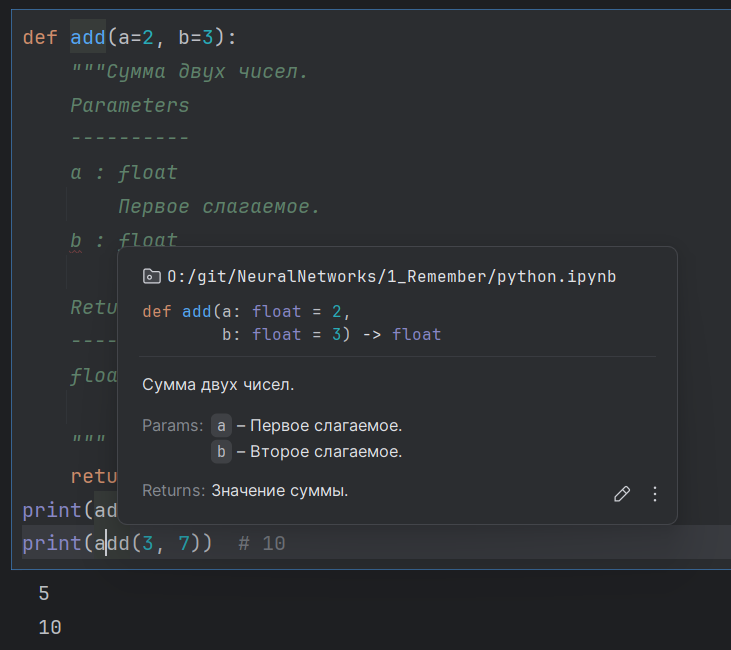

> Что такое класс? Чем функция отличается от метода? Как определить свой класс в питоне?  Чем класс отличается от экземпляра?

| Характеристика | Функция | Метод |
|---|---|---|
| Где живёт | Сама по себе (на уровне модуля) | Внутри класса |
| Как вызывается | `function_name()` | `object.method_name()` |
| Первый аргумент | Что передали, то и получила | Всегда `self` (экземпляр класса) |

In [19]:
import math

# ФУНКЦИЯ
def activation_sigmoid(x):
    """Сигмоидальная функция активации.
    Сжимает входное значение в интервал (0, 1).
    Отрицательные значения стремится к 0, положительные — к 1.

    Parameters
    ----------
    x : float
        Входное значение (любое вещественное число).

    Returns
    -------
    float
        Значение в интервале (0, 1).

    Examples
    --------
    >>> activation_sigmoid(0)
    0.5
    >>> activation_sigmoid(100)
    1.0
    >>> activation_sigmoid(-100)
    0.0
    """
    return 1 / (1 + math.e ** (-x))

result = activation_sigmoid(0.5)
print(f"activation_sigmoid(0.5) = {result:.4f}")

# КЛАСС с МЕТОДОМ
class Neuron:
    """Нейрон с сигмоидной функцией активации.

    Моделирует один искусственный нейрон. При создании получает имя,
    при активации вычисляет взвешенную сумму и применяет сигмоиду.
    """

    def __init__(self, name):
        """Инициализация нейрона.

        Parameters
        ----------
        name : str
            Имя нейрона.
        """
        self.name = name
        self.output = 0.0

    def activate(self, x):
        """Активация нейрона через сигмоиду.

        Сохраняет результат в self.output и возвращает его.

        Parameters
        ----------
        x : float
            Входной сигнал (взвешенная сумма входов + смещение).

        Returns
        -------
        float
            Выход нейрона в интервале (0, 1).
        """
        self.output = 1 / (1 + math.e ** (-x))
        print(f"Нейрон '{self.name}' активирован: вход={x}, выход={self.output:.4f}")
        return self.output

# Создание экземпляра (объекта) класса
neuron1 = Neuron(name="скрытый_слой_1")
neuron2 = Neuron(name="выходной_слой")

# Вызов МЕТОДА — через точку, у объекта
neuron1.activate(0.5)
print(f"neuron1.output : {neuron1.output:.4f}")
print(f"Получаем возврат от neuron2: {neuron2.activate(-0.3):.4f}")

activation_sigmoid(0.5) = 0.6225
Нейрон 'скрытый_слой_1' активирован: вход=0.5, выход=0.6225
neuron1.output : 0.6225
Нейрон 'выходной_слой' активирован: вход=-0.3, выход=0.4256
Получаем возврат от neuron2: 0.4256


> Что делают функции map и zip? Умеете ли вы ими пользоваться? Что делают выражения типа lambda x: x?